In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pywt

(-0.1, 52.0)

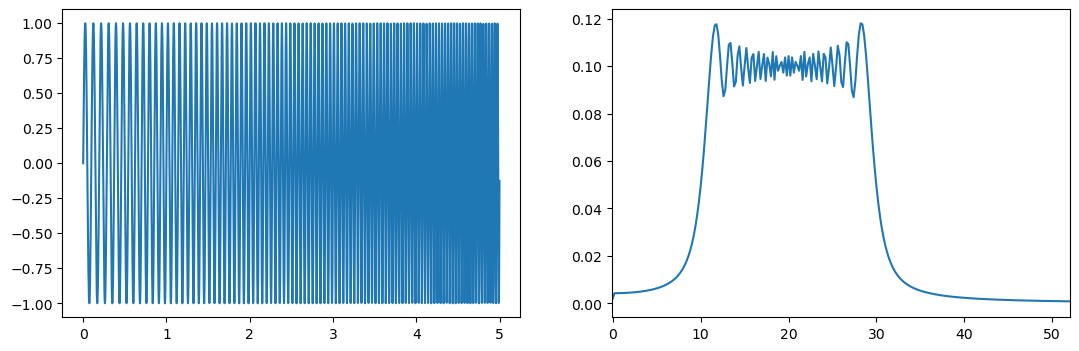

In [57]:
fs = 1000
t = np.arange(0, 5, 1/fs)
N = len(t)

f = [10, 30]
ff = np.linspace(f[0], np.mean(f), N)

chirp = np.sin(2 * np.pi * ff * t)

chirp_freq = 2 * np.abs(np.fft.rfft(chirp)) / N
chirp_freq[0] /= 2
hz = np.fft.rfftfreq(N, 1/fs)

plt.figure(figsize=(13, 4))
plt.subplot(121)
plt.plot(t, chirp)

plt.subplot(122)
plt.plot(hz, chirp_freq)
plt.xlim(-0.1, 52)

# STFFT (Short Time Fast Fourier Transform)

(79, 194)


Text(0.5, 1.0, 'Spectogram')

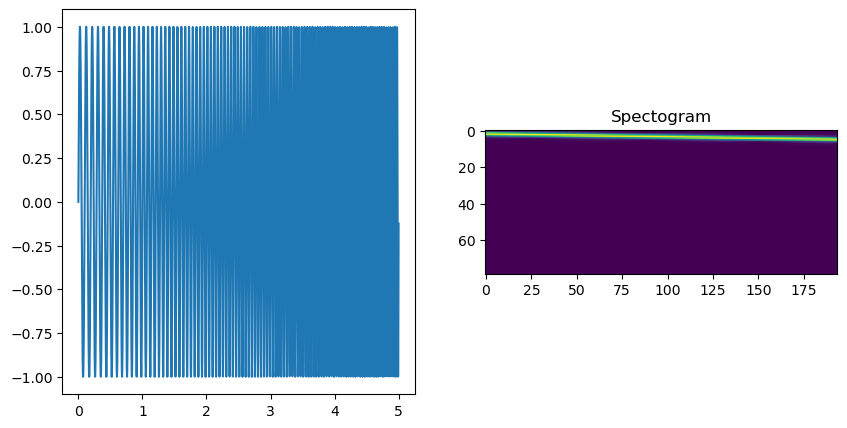

In [58]:
fs = 1000
t = np.arange(0, 5, 1 / fs)
N = len(t)

window_len = 157
stride = 25

Nsteps = (N - window_len) // stride + 1

hz = np.fft.rfftfreq(window_len, 1 / fs)
freq_arr = np.zeros(shape=(len(hz), Nsteps), dtype="complex")

# Calculation
last_idx = 0
for fi in range(Nsteps):
    sub_signal = chirp[last_idx : last_idx + window_len] * np.hanning(window_len)
    fCoeffs = np.fft.rfft(sub_signal) * 2 / N
    fCoeffs[0] /= 2

    freq_arr[:, fi] = fCoeffs
    last_idx += stride
# assert last_idx == N, f"OK what the fuck, we ended at {last_idx}"

print(freq_arr.shape)

# Plotting
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.plot(t, chirp)
plt.subplot(122)
plt.imshow(np.abs(freq_arr))
plt.title("Spectogram")

# Wavelet

100%|██████████| 2501/2501 [00:00<00:00, 5814.18it/s]


(-0.1, 54.0)

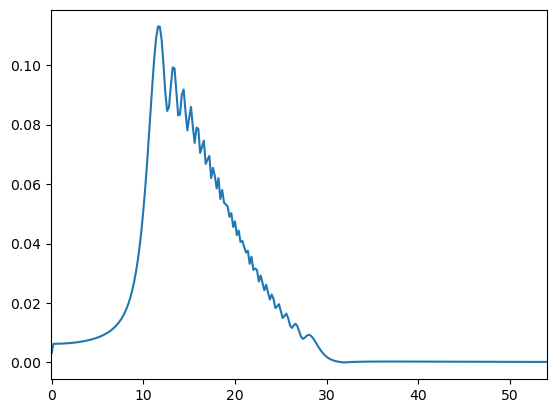

In [59]:
# without sliding (tau)
fs = 1000
t = np.arange(0, 5, 1 / fs)
N = len(t)
sigma = 0.5

# Chirp signal
f = [10, 30]
ff = np.linspace(f[0], np.mean(f), N)
chirp = np.sin(2 * np.pi * ff * t)
# End chirp signal

hz = np.fft.rfftfreq(N, 1 / fs)
freq_analysis = np.zeros((len(hz), 1), dtype="complex")  # btw what is a common good name for the iamge that is produced by this analysis thing?

for fi in tqdm(range(len(hz))):
    csw = np.exp(-1j * 2 * np.pi * hz[fi] * t)  # equivelent to ... * np.pi * fi * np.arange(0, N)/N right?
    gauss = np.exp(-(t**2) / 2 * sigma**2)
    wavelet = csw * gauss
    fCoeff = np.dot(wavelet, chirp)
    freq_analysis[fi] = fCoeff

freq_analysis = np.abs(2 / N * freq_analysis)
freq_analysis[0] /= 2

plt.plot(hz, freq_analysis)
plt.xlim(-0.1, 54)

Text(0.5, 1.0, 'The Great SCALOGRAM')

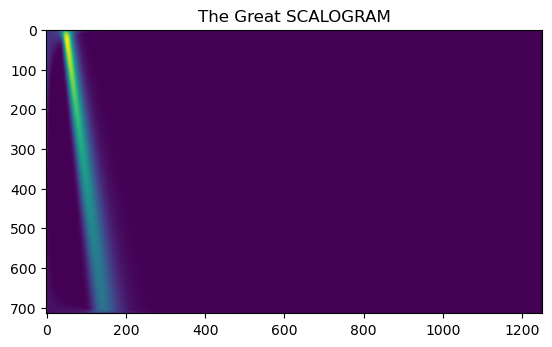

In [ ]:
# Spectogram generation (IT'S TAU TIME!)
fs = 500
t = np.arange(0, 5, 1 / fs)
N = len(t)
taus = np.arange(0, len(t) // fs, 0.007)
print(f"t length: {len(taus)}")
print(f"taus length: {len(taus)}")
print(f"hz length: {len(hz)}")

# Chirp signal
f = [10, 30]
ff = np.linspace(f[0], np.mean(f), N)
chirp = np.sin(2 * np.pi * ff * t)
# End chirp signal

hz = np.fft.rfftfreq(N, 1 / fs)
spectogram = np.zeros((len(taus), len(hz)), dtype='complex')

for fi in tqdm(range(len(hz))):
    freq = hz[fi]
    sigma = 6 / (2 * np.pi * freq)
    for ti, tau in enumerate(taus):
        csw = np.exp(-1j * 2 * np.pi * freq * (t - tau))  # equivelent to ... * np.pi * fi * np.arange(0, N)/N right?
        gauss = np.exp(-((t - tau) ** 2) / (2 * sigma**2))

        wavelet = csw * gauss
        fCoeff = np.dot(wavelet, chirp)
        spectogram[ti, fi] = fCoeff

spectogram *= 2/N
spectogram[:, 0] /= 2

plt.imshow(np.abs(spectogram))
plt.title("The Great SCALOGRAM")

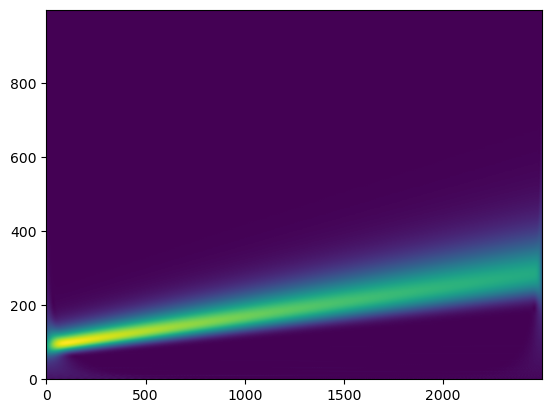

In [91]:
target_freqs = np.linspace(1, 100, 1000)
scales = (1 * fs) / target_freqs

coeffs, freqs = pywt.cwt(chirp, scales, 'cmor1.5-1.0')
plt.imshow(np.abs(coeffs), aspect='auto', origin='lower')